## Q1

In [ ]:
import pandas as pd

df = pd.read_csv("zomato.csv")

print(df.head())

print("\nDataset Info")
print(df.info())

print("\nSummary Statistics")
print(df.describe())

  restaurant_name   location       cuisine  cost  rating
0     Spice Villa  Ahmedabad  North Indian   800     4.5
1        Food Hub  Ahmedabad       Chinese   600     4.1
2      Pizza Town      Surat       Italian   900     4.6
3    Burger Point   Vadodara     Fast Food   450     3.8
4     Royal Thali     Rajkot      Gujarati   700     4.2

Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   restaurant_name  50 non-null     object 
 1   location         50 non-null     object 
 2   cuisine          50 non-null     object 
 3   cost             50 non-null     int64  
 4   rating           50 non-null     float64
dtypes: float64(1), int64(1), object(3)
memory usage: 2.1+ KB
None

Summary Statistics
              cost     rating
count    50.000000  50.000000
mean    665.800000   4.222000
std     225.778381   0.352999
min     300.0

## Q2

restaurant_name    0
location           0
cuisine            0
cost               0
rating             0
dtype: int64


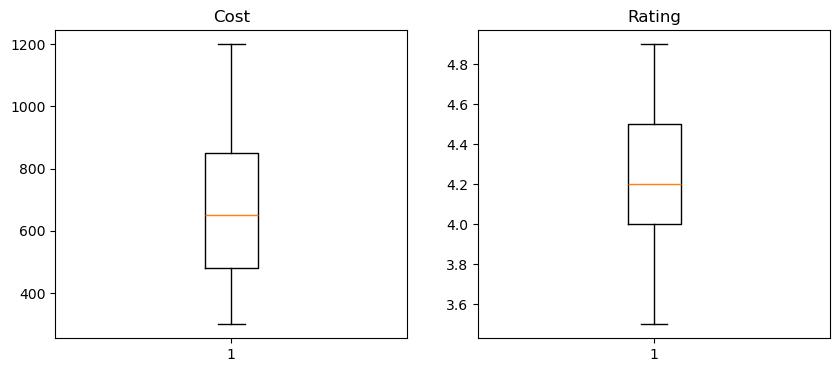

In [6]:
import numpy as np
import matplotlib.pyplot as plt

print(df.isnull().sum())

df["cost"] = df["cost"].fillna(df["cost"].median())
df["rating"] = df["rating"].fillna(df["rating"].median())

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.boxplot(df["cost"])
plt.title("Cost")

plt.subplot(1,2,2)
plt.boxplot(df["rating"])
plt.title("Rating")

plt.show()

## Q3

In [7]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

df = pd.get_dummies(
    df,
    columns=["cuisine", "location"],
    drop_first=True
)

scaler = StandardScaler()

df[["cost", "rating"]] = scaler.fit_transform(
    df[["cost", "rating"]]
)

print(df.head())

  restaurant_name      cost    rating  cuisine_Chinese  cuisine_Desserts  \
0     Spice Villa  0.600423  0.795534            False             False   
1        Food Hub -0.294395 -0.349119             True             False   
2      Pizza Town  1.047832  1.081697            False             False   
3    Burger Point -0.965508 -1.207609            False             False   
4     Royal Thali  0.153014 -0.062956            False             False   

   cuisine_Fast Food  cuisine_Gujarati  cuisine_Italian  cuisine_North Indian  \
0              False             False            False                  True   
1              False             False            False                 False   
2              False             False             True                 False   
3               True             False            False                 False   
4              False              True            False                 False   

   location_Rajkot  location_Surat  location_Vadodara  


## Q4

In [8]:
df["target"] = (df["rating"] > 4.0).astype(int)

In [11]:
from sklearn.model_selection import train_test_split

X = df.drop(
    ["target", "restaurant_name"],
    axis=1
)

y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)